# KNN Playlist Generator
**Purpose:** Given a playlist and n seed songs, generate a playlist using nearest neighbors. 

**Features:** BPM, Valence, Dance, Energy, Acoustic, Year, Popularity

**Steps:**
1. Select seed songs and map the feature space using K-means clustering.  
2. Pick k-nearest neighbors for each seed song to generate a playlist.

## Import Libraries

In [1]:
# Import necessary libraries for cluster analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from itertools import combinations
from adjustText import adjust_text

## Read Data

In [4]:
df_playlist = pd.read_csv('../data/music_library.csv')
df_playlist

,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,Album,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,#1,Nelly,180,9B,59,2026-03-10,03:18,57,NaN,Nellyville,...,46,30,50,-6,G Major,4,7rSj5gEdN5KgHwbnEVAZ4b,USUR10200366,Rap-R&B,2002
1,#1 Crush - Nellee Hooper Mix,"Garbage,Nellee Hooper",94,7B,63,2026-03-30,04:50,51,NaN,Garbage (20th Anniversary Deluxe Edition/Remas...,...,49,0,30,-7,F Major,4,08L1WAtYQnsFBoZ3MEBkYV,GBPVV1501060,Liked Songs,1995
2,#88,Lo-Fang,135,9B,34,2026-03-16,05:48,0,NaN,#88,...,40,0,0,-10,G Major,4,1jjwFHRnfgBTJ049RJz8CQ,GBAFL2000240,Alternative,2013
3,&Run,Sir Sly,92,7B,66,2026-03-02,03:46,60,NaN,"Don't You Worry, Honey",...,48,0,10,-8,F Major,4,0w4m3Xp4svlIoyL94Zjlyd,USUM71704895,Liked Songs,2017
4,(I Can't Get No) Satisfaction - Mono,The Rolling Stones,136,10B,86,2026-03-16,03:42,74,"classic rock, rock",Out Of Our Heads,...,93,0,10,-8,D Major,4,2PzU4IB8Dr6mxV3lHuaG34,USA176510160,Rock,1965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,wet dreams,Artemas,126,9B,72,2026-03-02,01:39,54,NaN,wet dreams,...,4,0,20,-6,G Major,4,05EXzecgWqEuk5ph43jRq9,QZJ842401770,Liked Songs,2024
1780,yeti,"Paris Paloma,Old Sea Brigade",139,10A,39,2026-03-30,04:12,49,"indie folk, folk pop",Cacophony,...,25,0,10,-11,B Minor,4,09cCZPsr05CpO15RgnHCr7,CAN112300618,Liked Songs,2024
1781,you should see me in a crown,Billie Eilish,150,12B,53,2026-03-02,03:00,77,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,32,10,10,-10,E Major,4,3XF5xLJHOQQRbWya6hBp7d,USUM71810049,Liked Songs,2019
1782,you've been a bad girl,Artemas,137,9A,87,2026-03-30,02:23,60,NaN,yustyna,...,37,0,10,-2,E Minor,4,6Gron8VFcNPwj7ZamJe7Pt,QZJ842401766,Liked Songs,2024


## Environment Variables

In [3]:
# === CONFIG ===
METADATA = ['Song', 'Artist', 'Album', 'Playlist', 'Album Year', 'Popularity']
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic', 'Loud (Db)']

# Hip hop playlist
df_hip_hop_metadata = df_playlist[df_playlist['Playlist'] == 'Rap-R&B'][METADATA]
df_hip_hop_features = df_playlist[df_playlist['Playlist'] == 'Rap-R&B'][FEATURES]

# Alternative playlist
df_alternative_metadata = df_playlist[df_playlist['Playlist'] == 'Alternative'][METADATA]
df_alternative_features = df_playlist[df_playlist['Playlist'] == 'Alternative'][FEATURES]

# Verify
print(f"Songs: {len(df_hip_hop_metadata)} in Hip Hop Playlist, {len(df_alternative_metadata)} in Alternative")
print(f"Features: {FEATURES}")
print(f"Missing features: {df_playlist[FEATURES].isna().sum().sum()}")

Songs: 0 in Hip Hop Playlist, 0 in Alternative
Features: ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic', 'Loud (Db)']
Missing features: 0


## Generate Playlist

### 1. Select Seed Songs and Map Space

In [4]:
## == HELPER FUNCTIONS: SEED SONGS ===

# Collect seed songs into a DataFrame
def collect_seeds(df_playlist_metadata, df_playlist_features, seed_songs_dict):
    """
    Collect seed song data into a DataFrame.
    
    Parameters:
    - seed_songs_dict: dict of {song_name: artist_name}
    
    Returns:
    - df_seeds: DataFrame with song, artist, popularity, year, and FEATURES
    """
    seeds = []
    for song, artist in seed_songs_dict.items():
        result = get_song_features(df_playlist_metadata, df_playlist_features, song, artist)
        if result:
            seeds.append({
                'song': song,
                'artist': artist,
                'features': result['features'],
                'popularity': result['popularity'],
                'year': result['year']
            })
    
    df_seeds = pd.DataFrame(seeds)
    df_seeds[FEATURES] = pd.DataFrame(df_seeds['features'].tolist(), index=df_seeds.index)
    df_seeds = df_seeds.drop(columns=['features'])
    
    print("\n" + "="*50)
    print("SEED SUMMARY")
    print("="*50)
    print(df_seeds)
    
    return df_seeds

# Get song features
def get_song_features(df_playlist_metadata, df_playlist_features, song_name, artist_name=None):
    mask = df_playlist_metadata['Song'].str.contains(song_name, case=False, na=False)
    if artist_name:
        mask = mask & df_playlist_metadata['Artist'].str.contains(artist_name, case=False, na=False)
    
    if mask.sum() == 0:
        print(f"Couldn't find '{song_name}'" + (f" by '{artist_name}'" if artist_name else ""))
        return None
    
    idx = df_playlist_metadata[mask].index[0]
    meta = df_playlist_metadata.loc[idx]
    feats = df_playlist_features.loc[idx]

    print(f"• {meta['Song']} — {meta['Artist']} ({meta['Album Year']})")
    print(f"  Popularity: {meta['Popularity']}")
    for feature in FEATURES:
        print(f"  {feature}: {feats[feature]}")
    print('\n')
    
    return {
    'features': [int(feats[f]) for f in FEATURES],
    'popularity': int(meta['Popularity']),
    'year': int(meta['Album Year'])
    }

In [5]:
def visualize_seeds(df_playlist_features, df_seeds):
    """
    Visualize seed placement in feature space using pairwise feature plots.
    Clusters in the original 8-dimensional space, no PCA reduction.
    """
    # --- Scale features ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    
    # --- Find best k ---
    def get_best_k(X_scaled, k_range=(3, 11)):
        scores = {}
        for k in range(k_range[0], k_range[1]):
            km = KMeans(n_clusters=k, n_init=50, random_state=42)
            labels = km.fit_predict(X_scaled)
            scores[k] = silhouette_score(X_scaled, labels)
        best_k = max(scores, key=scores.get)
        return best_k, scores
    
    best_k, scores = get_best_k(X_scaled)
    
    # --- Cluster ---
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # --- Transform seeds ---
    seeds_scaled = scaler.transform(df_seeds[FEATURES])
    seed_clusters = kmeans.predict(seeds_scaled)
    seed_distances = [
        np.linalg.norm(seeds_scaled[i] - kmeans.cluster_centers_[seed_clusters[i]])
        for i in range(len(seeds_scaled))
    ]
    
    # --- Plot setup ---
    feature_names = df_playlist_features.columns.tolist()
    plot_pairs = [
        ('Energy', 'Acoustic'),
        ('Valence', 'Energy'),
        ('BPM', 'Dance'),
        ('Loud (Db)', 'Energy'),
        ('Valence', 'Dance'),
        ('BPM', 'Valence'),
    ]
    pairs = [(feature_names.index(a), feature_names.index(b)) for a, b in plot_pairs]
    
    n_plots = len(pairs)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()
    
    # --- PLOTTING LOOP ---
    for ax, (i, j) in zip(axes, pairs):
        # Scatter all songs
        ax.scatter(X_scaled[:, i], X_scaled[:, j], c=clusters, cmap='viridis', alpha=0.5)
        
        # Scatter seed songs
        ax.scatter(seeds_scaled[:, i], seeds_scaled[:, j],
                   c='red', s=150, edgecolors='black', linewidths=2, label='Seeds', zorder=5)
        
        # Annotate seed songs
        texts = []
        for pos, (idx, row) in enumerate(df_seeds.iterrows()):
            t = ax.annotate(row['song'], (seeds_scaled[pos, i], seeds_scaled[pos, j]),
                            fontsize=8, ha='left', va='bottom')
            texts.append(t)
        
        # Repel overlapping labels
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
        
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(feature_names[j])
        ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")
    # --- END OF PLOTTING LOOP ---
    
    # Add seed legend
    seed_names = df_seeds['song'].tolist()
    legend_text = "Seeds:\n" + "\n".join(f"• {name}" for name in seed_names)
    fig.text(0.98, 0.5, legend_text, fontsize=12, va='center', ha='left',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.9),
             transform=fig.transFigure)
    
    plt.subplots_adjust(right=0.95)
    plt.show()

In [6]:
# Hip Hop playlist
seed_songs_dict_hip_hop = {
    "Can't C Me": "2Pac",
    "Forgot About Dre": "Dr. Dre", 
    "Dance With Me": "112", 
    "Heated": "Beyoncé",
    "Like That": "Memphis Bleek"
}

# Alternative playlist
seed_songs_dict_alternative = {
    "Dissolve": "Absofacto,NITESHIFT", 
    "Trip Switch": "Nothing But Thieves",
    "Blossom": "Milky Chance",
    "Body Heat": "Goldie Boutilier", 
    "Cowboy Gangster Politician": "Goldie Boutilier"
}

• Can't C Me — 2Pac (1996)
  Popularity: 70
  BPM: 95
  Dance: 80
  Energy: 85
  Valence: 67
  Acoustic: 4
  Loud (Db): -2


• Forgot About Dre — Dr. Dre,Eminem (1999)
  Popularity: 80
  BPM: 134
  Dance: 92
  Energy: 74
  Valence: 62
  Acoustic: 8
  Loud (Db): -1


• Dance With Me — 112 (2001)
  Popularity: 66
  BPM: 102
  Dance: 91
  Energy: 51
  Valence: 61
  Acoustic: 3
  Loud (Db): -6


• HEATED — Beyoncé (2022)
  Popularity: 67
  BPM: 111
  Dance: 79
  Energy: 73
  Valence: 50
  Acoustic: 6
  Loud (Db): -6


• Like That — Memphis Bleek (2005)
  Popularity: 48
  BPM: 98
  Dance: 91
  Energy: 91
  Valence: 58
  Acoustic: 6
  Loud (Db): -3



SEED SUMMARY
               song         artist  popularity  year  BPM  Dance  Energy  \
0        Can't C Me           2Pac          70  1996   95     80      85   
1  Forgot About Dre        Dr. Dre          80  1999  134     92      74   
2     Dance With Me            112          66  2001  102     91      51   
3            Heated        Be

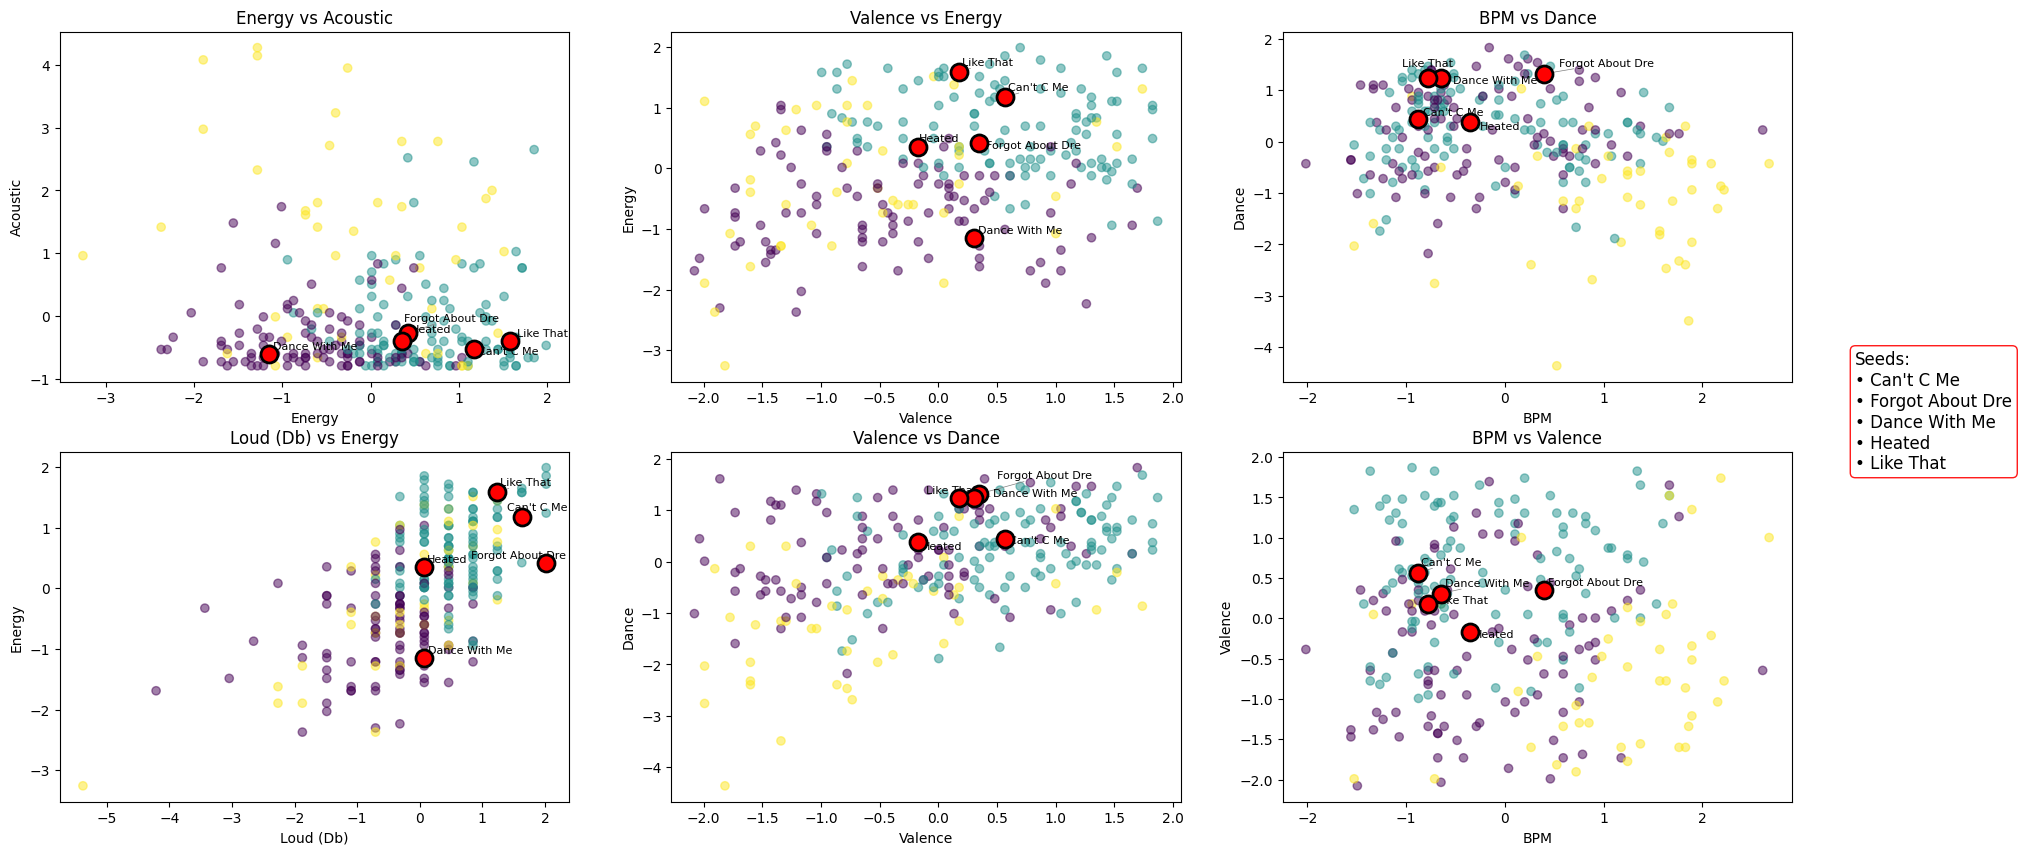

In [7]:
df_seeds_hip_hop = collect_seeds(df_hip_hop_metadata, df_hip_hop_features, seed_songs_dict_hip_hop)
result_hip_hop = visualize_seeds(df_hip_hop_features, df_seeds_hip_hop)

• Dissolve — Absofacto,NITESHIFT (2024)
  Popularity: 57
  BPM: 85
  Dance: 69
  Energy: 58
  Valence: 87
  Acoustic: 23
  Loud (Db): -11


• Trip Switch — Nothing But Thieves (2015)
  Popularity: 53
  BPM: 88
  Dance: 65
  Energy: 81
  Valence: 77
  Acoustic: 2
  Loud (Db): -4


• Blossom — Milky Chance (2017)
  Popularity: 47
  BPM: 120
  Dance: 75
  Energy: 68
  Valence: 85
  Acoustic: 3
  Loud (Db): -7


• Body Heat — Goldie Boutilier (2022)
  Popularity: 62
  BPM: 115
  Dance: 88
  Energy: 53
  Valence: 88
  Acoustic: 14
  Loud (Db): -9


• Cowboy Gangster Politician — Goldie Boutilier (2022)
  Popularity: 70
  BPM: 130
  Dance: 67
  Energy: 70
  Valence: 63
  Acoustic: 21
  Loud (Db): -7



SEED SUMMARY
                         song               artist  popularity  year  BPM  \
0                    Dissolve  Absofacto,NITESHIFT          57  2024   85   
1                 Trip Switch  Nothing But Thieves          53  2015   88   
2                     Blossom         Milky Chance

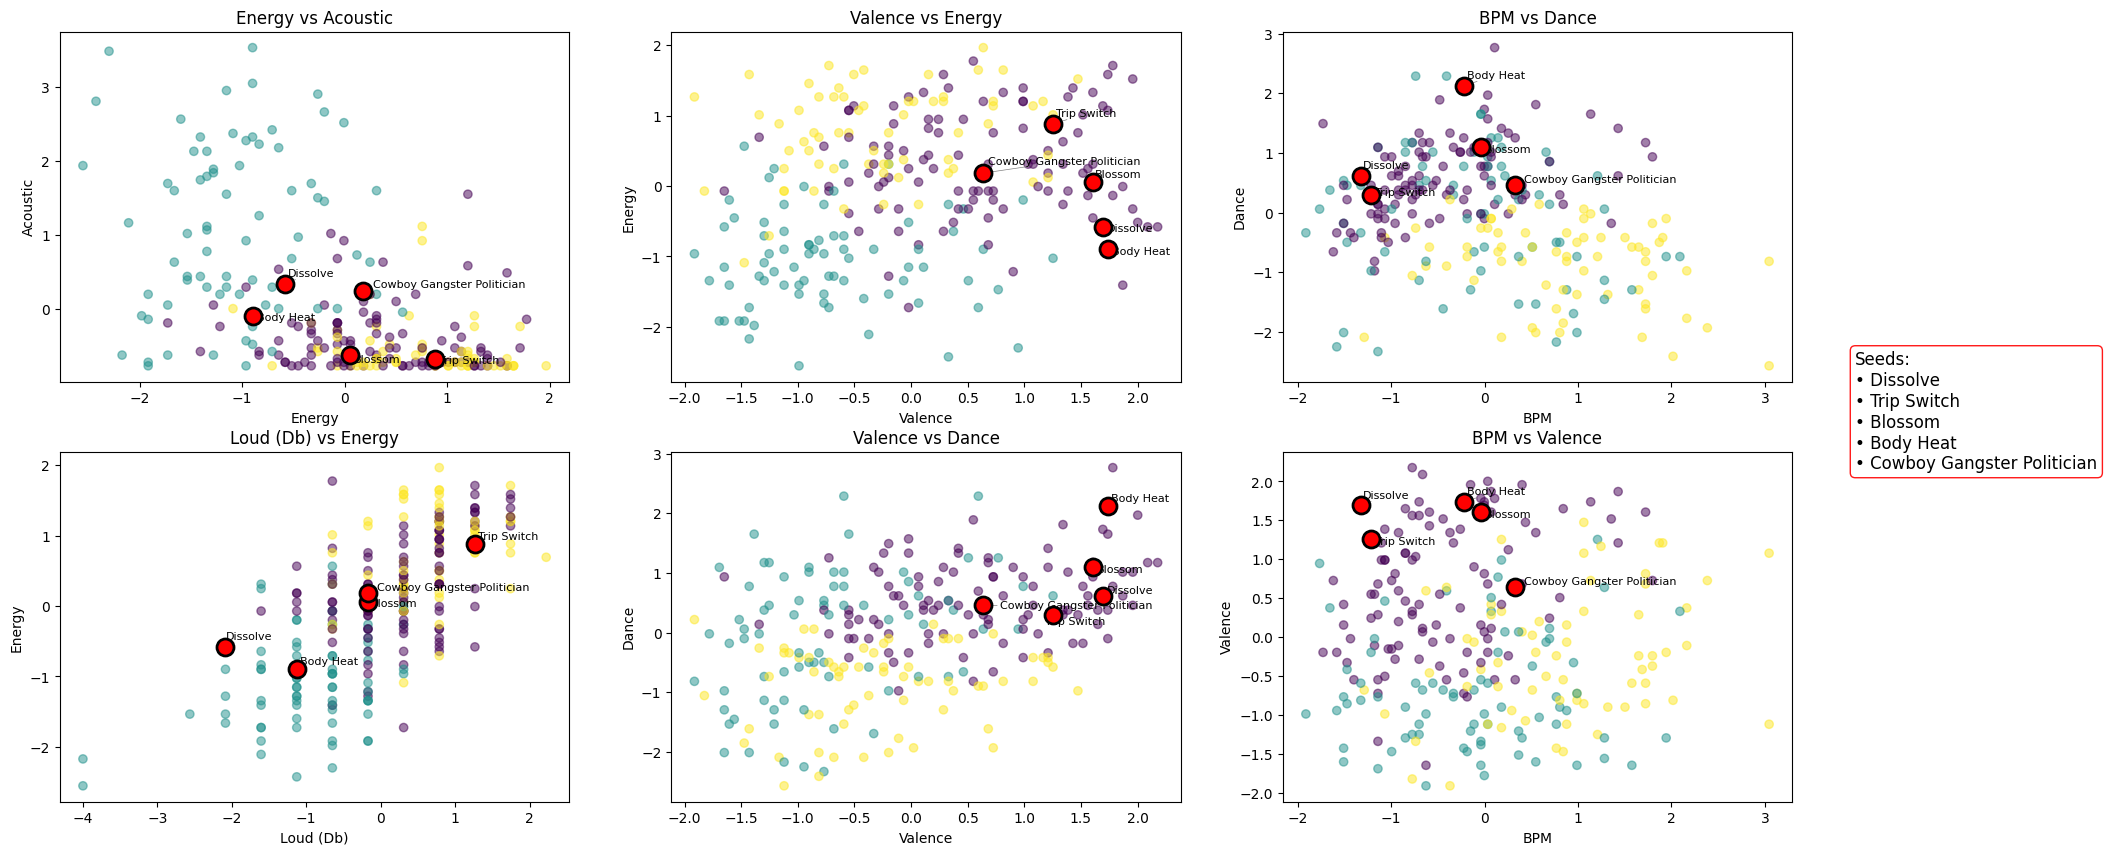

In [8]:
df_seeds_alternative = collect_seeds(df_alternative_metadata, df_alternative_features, seed_songs_dict_alternative)
result_alternative = visualize_seeds(df_alternative_features, df_seeds_alternative)

### 2. Select K-Nearest Neighbors for each song

In [9]:
## == HELPER FUNCTIONS ===

def find_similar_songs(df_playlist_metadata, df_playlist_features, target, n=10):
    """
    Find similar songs using KNN on audio features.
    
    Parameters:
    - target: list of feature values [BPM, Dance, Energy, Valence, Acoustic]
    - n: number of neighbors to return
    """
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=n, metric='euclidean')
    knn.fit(X_scaled)
    
    # Scale target and get neighbors
    target_df = pd.DataFrame([target], columns=FEATURES)
    target_scaled = scaler.transform(target_df)[0]
    distances, indices = knn.kneighbors([target_scaled])
    
    # Build results
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        meta = df_playlist_metadata.iloc[idx]
        feats = df_playlist_features.iloc[idx]
        results.append({
            'song': meta['Song'],
            'artist': meta['Artist'],
            'year': meta['Album Year'],
            'popularity': meta['Popularity'],
            'distance': round(dist, 3),
            **{f: feats[f] for f in FEATURES}
        })
    
    df_neighbors = pd.DataFrame(results)
    
    # Print
    print(f"Target: {dict(zip(FEATURES, target))}\n")
    for _, row in df_neighbors.iterrows():
        print(f"{row['song']} — {row['artist']} ({row['year']}) | dist: {row['distance']}")
    
    return df_neighbors

def generate_playlist(df_playlist_metadata, df_playlist_features, df_seeds, n_per_seed=10):
    """
    Generate a playlist by finding KNN neighbors for each seed song.
    
    Parameters:
    - df_seeds: DataFrame from collect_seeds()
    - n_per_seed: neighbors per seed (10 = ~50 songs after deduping)
    
    Returns:
    - DataFrame of unique songs sorted by BPM, Valence, Dance
    """
    all_neighbors = []
    
    for _, seed in df_seeds.iterrows():
        target = [seed[f] for f in FEATURES]
        neighbors = find_similar_songs(df_playlist_metadata, df_playlist_features, target, n=n_per_seed)
        all_neighbors.append(neighbors)
        print()  # spacing between seeds
    
    # Combine and dedupe
    df_playlist = (
        pd.concat(all_neighbors)
        .drop_duplicates(subset=['song', 'artist'])
        .sort_values(['BPM', 'Valence', 'Dance'])
        .reset_index(drop=True)
    )
    
    # Summary
    print("=" * 50)
    print(f"GENERATED PLAYLIST (n={len(df_playlist)})")
    print("=" * 50)
    print(f"Mean: { {f: round(df_playlist[f].mean(), 2) for f in FEATURES} }")
    print(f"Std:  { {f: round(df_playlist[f].std(), 2) for f in FEATURES} }")
    
    return df_playlist

In [10]:
def visualize_playlist(df_playlist_features, df_playlist, df_seeds, title="KNN Playlist"):
    """
    Visualize where a generated playlist lands in the full library's feature space.
    
    Args:
        df_playlist_features: Full library features (for background context)
        df_playlist: The generated playlist with features
        df_seeds: The seed songs dataframe
        title: Plot title
    """
    # --- Scale using full library ---
    scaler = StandardScaler()
    X_library = scaler.fit_transform(df_playlist_features)
    
    # --- Scale playlist songs ---
    playlist_features = df_playlist[FEATURES]
    X_playlist = scaler.transform(playlist_features)
    
    # --- Separate seeds from KNN picks ---
    seed_songs = df_seeds['song'].tolist()
    seed_songs_lower = df_seeds['song'].str.strip().str.lower().tolist()
    is_seed = df_playlist['song'].str.strip().str.lower().isin(seed_songs_lower)
    X_seeds = X_playlist[is_seed.values]
    X_knn = X_playlist[~is_seed.values]

    
    # --- Plot setup ---
    feature_names = FEATURES
    plot_pairs = [
        ('Energy', 'Acoustic'),
        ('Valence', 'Energy'),
        ('BPM', 'Dance'),
        ('Loud (Db)', 'Energy'),
        ('Valence', 'Dance'),
        ('BPM', 'Valence'),
    ]
    pairs = [(feature_names.index(a), feature_names.index(b)) for a, b in plot_pairs]
    
    n_plots = len(pairs)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()
    
    for ax, (i, j) in zip(axes, pairs):
        # Background: full library (gray, faded)
        ax.scatter(X_library[:, i], X_library[:, j], c='lightgray', alpha=0.3, s=30, label='Library')
        
        # KNN picks (blue)
        ax.scatter(X_knn[:, i], X_knn[:, j], c='dodgerblue', s=80, edgecolors='white', 
                   linewidths=1, alpha=0.8, label='KNN picks')
        
        # Seeds (red)
        ax.scatter(X_seeds[:, i], X_seeds[:, j], c='red', s=150, edgecolors='black', 
                   linewidths=2, label='Seeds', zorder=5)
        
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(feature_names[j])
        ax.set_title(f'{feature_names[i]} vs {feature_names[j]}')
    
    axes[0].legend()
    
    # Seed legend on right
    legend_text = "Seeds:\n" + "\n".join(f"• {name}" for name in seed_songs)
    fig.text(0.98, 0.5, legend_text, fontsize=12, va='center', ha='left',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.9),
             transform=fig.transFigure)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()

Target: {'BPM': 95, 'Dance': 80, 'Energy': 85, 'Valence': 67, 'Acoustic': 4, 'Loud (Db)': -2}

Can't C Me — 2Pac (1996) | dist: 0.0
How Many Licks? (feat. Sisqo) — Lil' Kim,Sisqo (2000) | dist: 0.539
Bootylicious — Destiny's Child (2001) | dist: 0.921
Jump — Tyla,Gunna,Skillibeng (2024) | dist: 1.001
Butterfly — Crazy Town (2000) | dist: 1.046
Like That — Memphis Bleek (2005) | dist: 1.067
Still D.R.E. — Dr. Dre,Snoop Dogg (1999) | dist: 1.176
AM To PM — Christina Milian (2001) | dist: 1.213
Love Like — Kehlani (2024) | dist: 1.385
N.Y.C. — Kevin Rudolf,Nas (2008) | dist: 1.473

Target: {'BPM': 134, 'Dance': 92, 'Energy': 74, 'Valence': 62, 'Acoustic': 8, 'Loud (Db)': -1}

Forgot About Dre — Dr. Dre,Eminem (1999) | dist: 0.0
Snap Backs & Tattoos — Driicky Graham (2012) | dist: 1.378
Jump — Tyla,Gunna,Skillibeng (2024) | dist: 1.69
Kiss Kiss (feat. T-Pain) — Chris Brown,T-Pain (2007) | dist: 1.728
The Real Slim Shady — Eminem (2000) | dist: 1.755
How Many Licks? (feat. Sisqo) — Lil' Kim

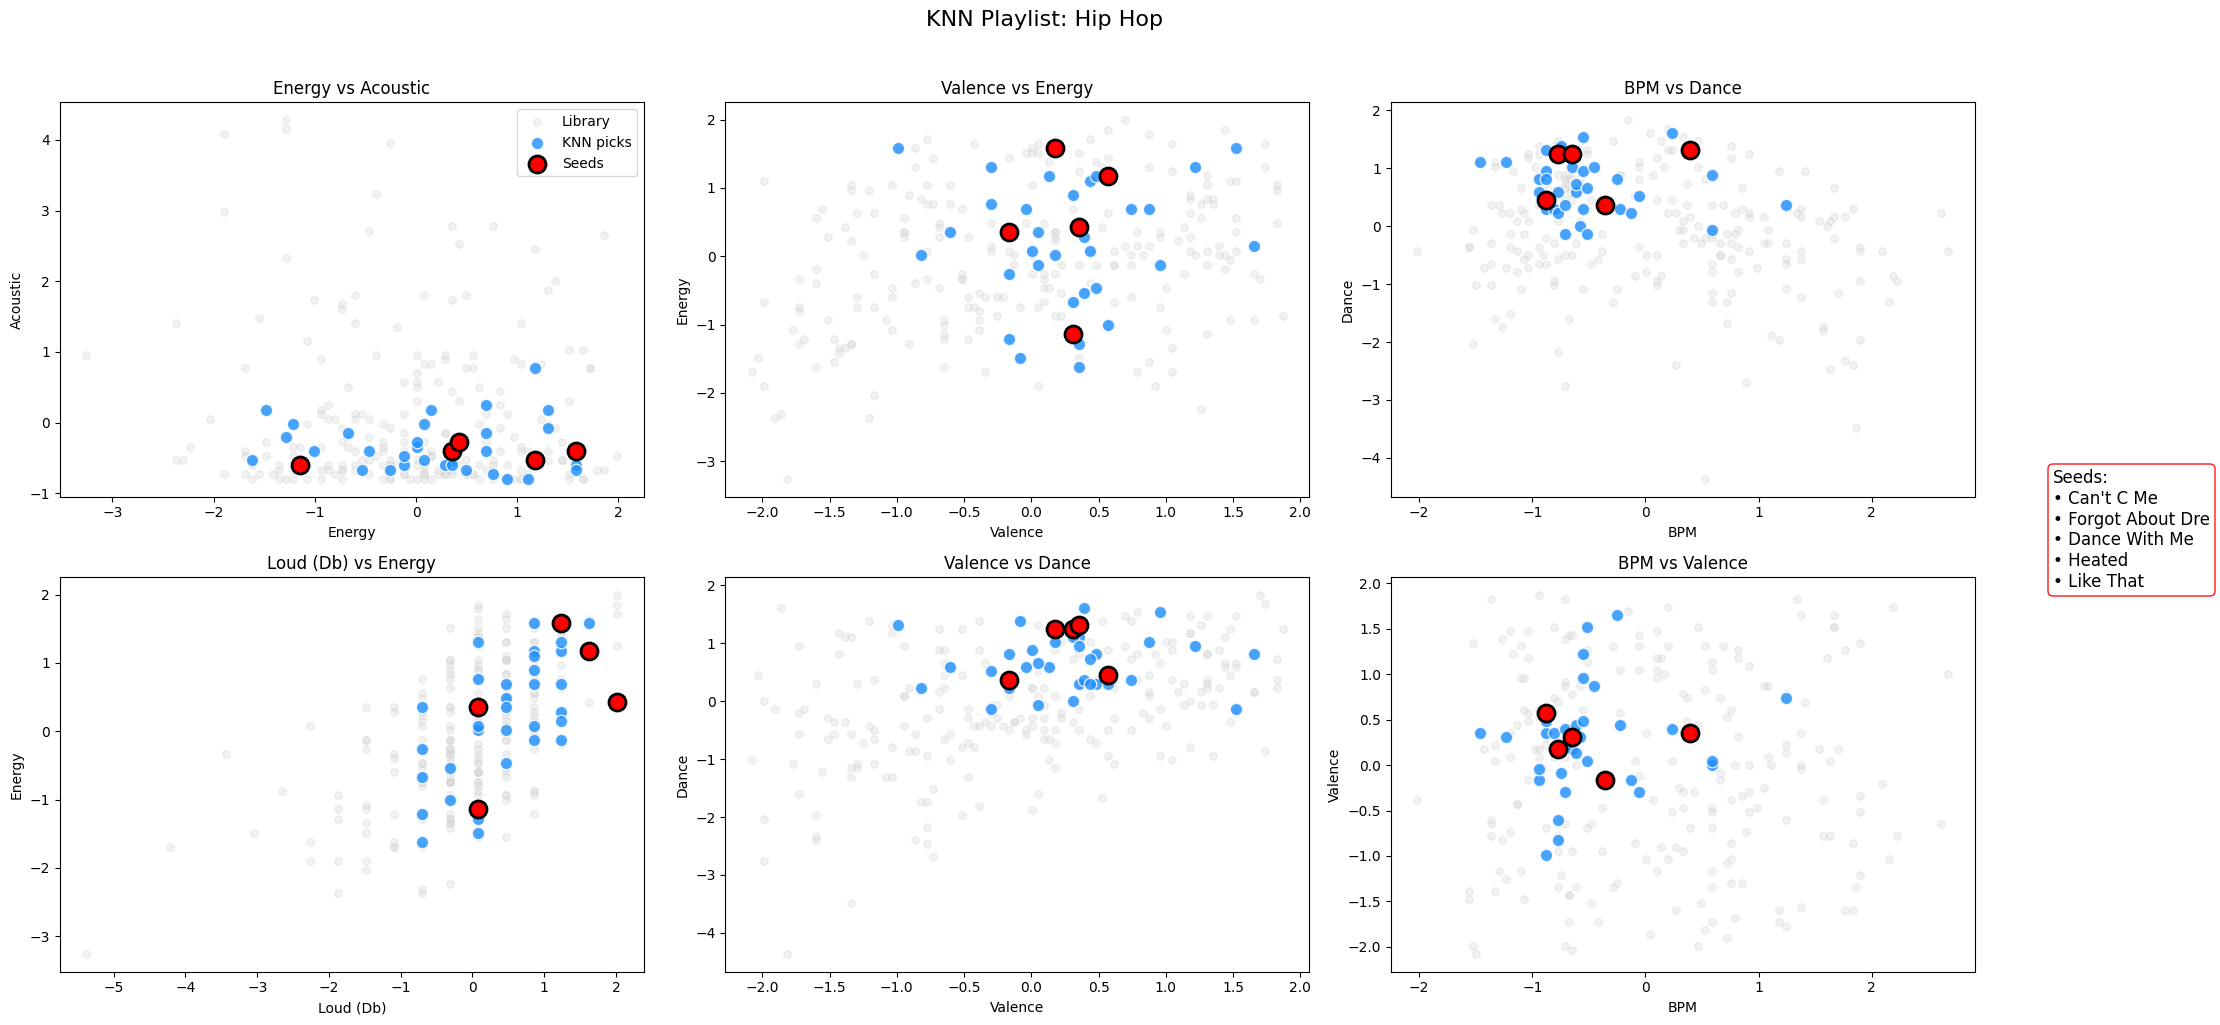

,song,artist,year,popularity,distance,BPM,Dance,Energy,Valence,Acoustic,Loud (Db)
0,Laffy Taffy,D4L,2005,69,1.235,77,89,44,62,4,-8
1,It's Goin' Down (feat. Nitti),"Yung Joc,NITTI",2006,70,1.186,84,89,58,61,10,-8
2,Magic Stick,Lil' Kim,2003,63,1.208,93,85,50,50,12,-8
3,Still D.R.E.,"Dr. Dre,Snoop Dogg",1999,84,1.176,93,82,78,53,16,-3
4,The Next Episode,"Dr. Dre,Snoop Dogg",1999,81,1.256,95,92,91,31,3,-2
5,Fish Paste,Die Antwoord,2010,38,0.556,95,87,49,62,9,-6
6,It Wasn't Me,"Shaggy,Rik Rok",2000,82,0.963,95,85,61,65,6,-5
7,Thrift Shop (feat. Wanz),"Macklemore & Ryan Lewis,Macklemore,Ryan Lewis,...",2012,67,1.106,95,78,53,67,6,-7
8,Can't C Me,2Pac,1996,70,0.000,95,80,85,67,4,-2
9,Love Like,Kehlani,2024,40,1.385,97,78,75,62,2,-5


In [11]:
# Playlist from df_seeds_hip_hop
df_playlist_hip_hop = generate_playlist(df_playlist_metadata=df_hip_hop_metadata, 
                                        df_playlist_features=df_hip_hop_features, 
                                        df_seeds=df_seeds_hip_hop, 
                                        n_per_seed=10)

# Visualize playlist
visualize_playlist(df_playlist_features=df_hip_hop_features,
                   df_playlist=df_playlist_hip_hop, 
                   df_seeds=df_seeds_hip_hop, 
                   title="KNN Playlist: Hip Hop")

# Save playlist
df_playlist_hip_hop.to_csv('../results/knn_playlist_hip_hop.csv', index=False)
df_playlist_hip_hop

Target: {'BPM': 85, 'Dance': 69, 'Energy': 58, 'Valence': 87, 'Acoustic': 23, 'Loud (Db)': -11}

Dissolve — Absofacto,NITESHIFT (2024) | dist: 0.0
Pretty Pimpin — Kurt Vile (2015) | dist: 1.682
Don't You Know — Jaymes Young (2017) | dist: 1.733
Not Enough — Daughter (2026) | dist: 1.848
Youth — Glass Animals (2016) | dist: 1.865
Doing Good — Milky Chance (2017) | dist: 1.921
Devil's Advocate — The Neighbourhood (2020) | dist: 1.921
Pork Soda — Glass Animals (2016) | dist: 1.996
Black Sun — Death Cab for Cutie (2015) | dist: 2.004
Wonderful Nothing — Glass Animals (2024) | dist: 2.078

Target: {'BPM': 88, 'Dance': 65, 'Energy': 81, 'Valence': 77, 'Acoustic': 2, 'Loud (Db)': -4}

Trip Switch — Nothing But Thieves (2015) | dist: 0.0
Take My Love and Run — Bad Suns (2014) | dist: 0.655
Something to Believe In — Young the Giant (2016) | dist: 0.798
Electric Bones — Findlay (2017) | dist: 0.834
home ft. WALK THE MOON — MORGXN,WALK THE MOON (2018) | dist: 0.854
Obsession — Joywave (2020) | di

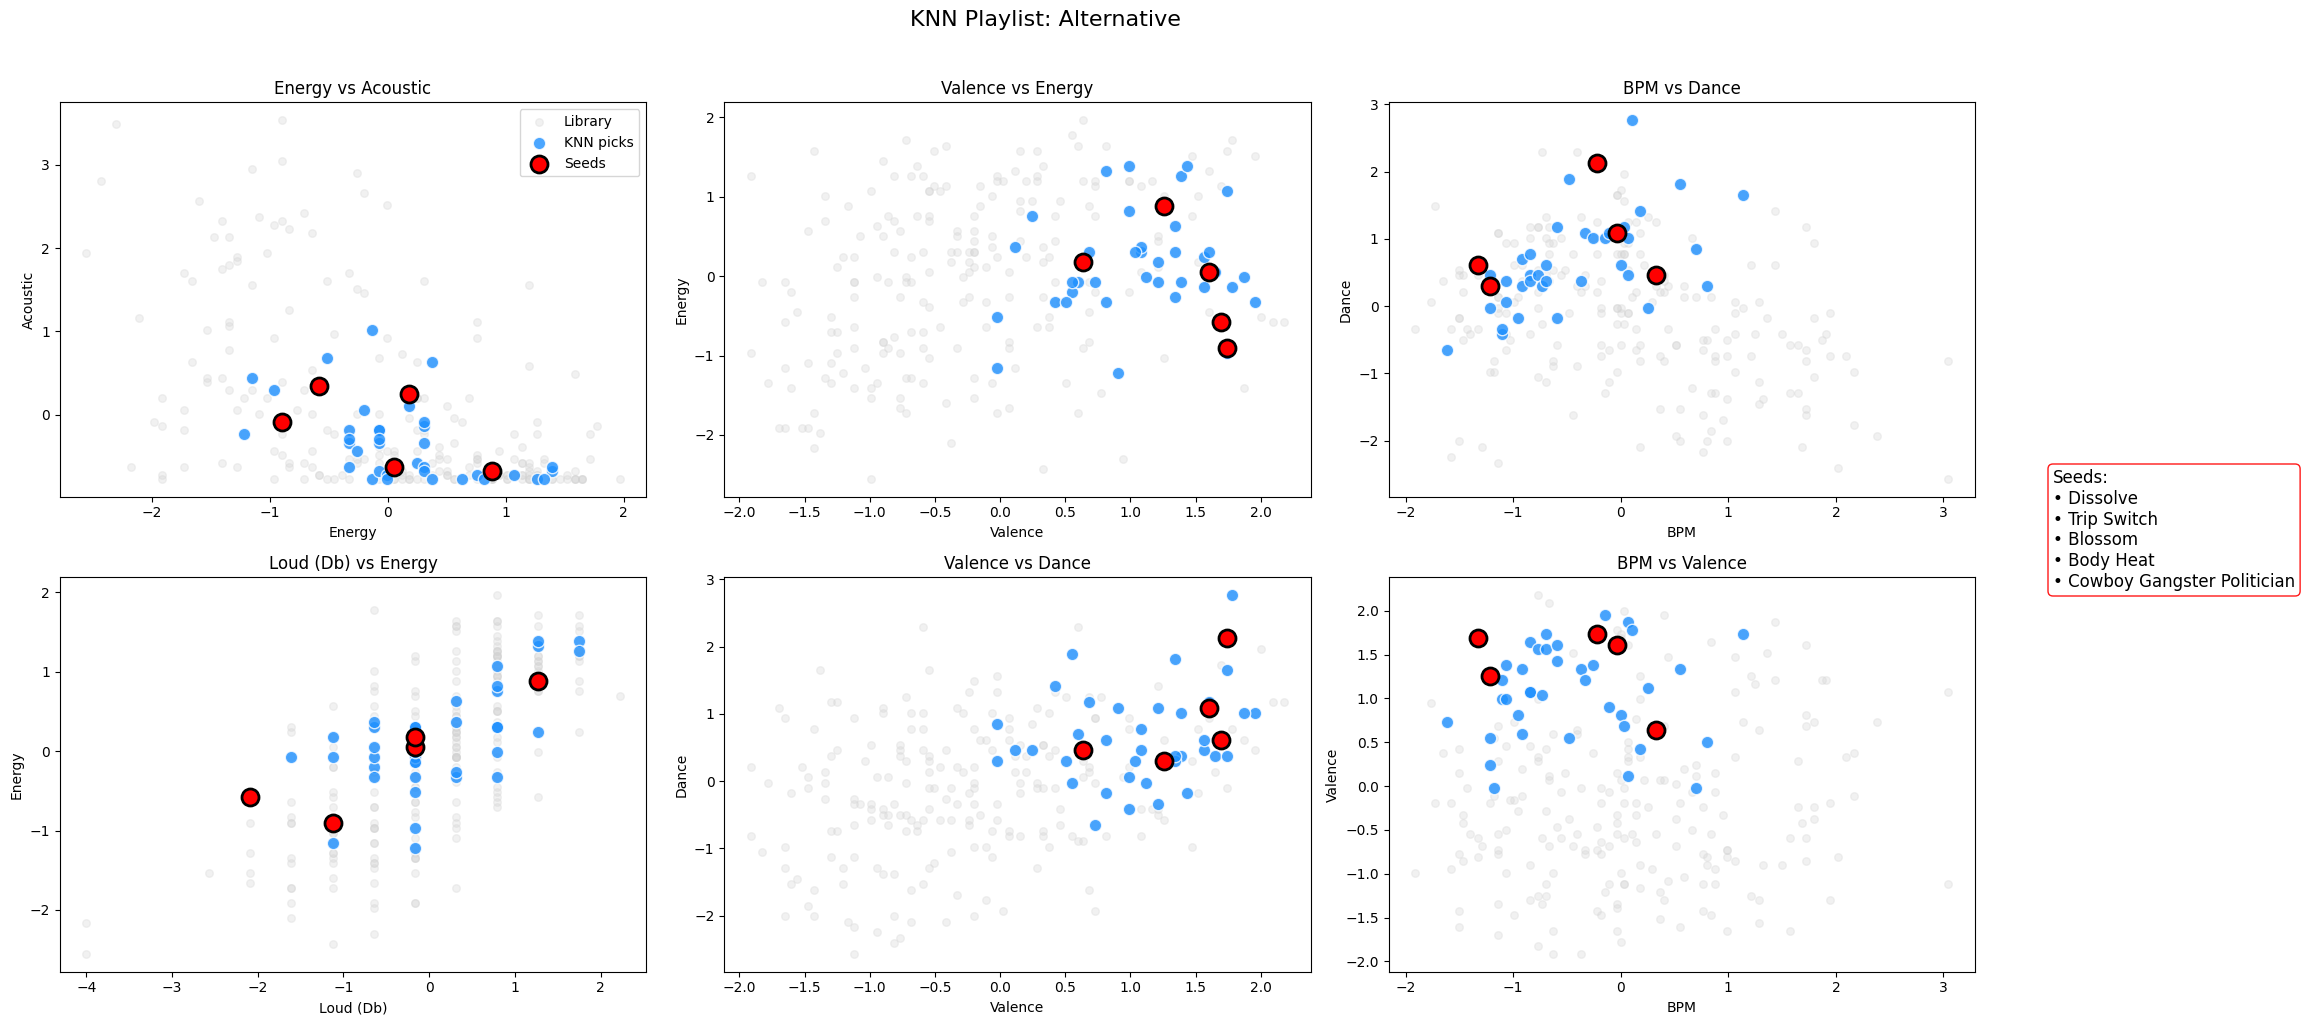

,song,artist,year,popularity,distance,BPM,Dance,Energy,Valence,Acoustic,Loud (Db)
0,Not Enough,Daughter,2026,44,1.848,77,53,66,65,12,-10
1,Dissolve,"Absofacto,NITESHIFT",2024,57,0.000,85,69,58,87,23,-11
2,Missed Connection,The Head And The Heart,2019,53,1.139,88,67,79,54,1,-5
3,Black Sun,Death Cab for Cutie,2015,53,2.004,88,61,64,61,17,-8
4,Trip Switch,Nothing But Thieves,2015,53,0.000,88,65,81,77,2,-4
5,Wonderful Nothing,Glass Animals,2024,60,2.078,89,65,49,48,25,-9
6,Milk & Coffee,NoMBe,2018,51,0.915,91,56,80,71,0,-5
7,Pretty Pimpin,Kurt Vile,2015,57,1.682,91,57,66,76,9,-9
8,Something to Believe In,Young the Giant,2016,61,0.798,92,62,89,71,2,-3
9,Take My Love and Run,Bad Suns,2014,41,0.655,92,66,87,80,0,-3


In [12]:
# Playlist from df_seeds_alternative
df_playlist_alternative = generate_playlist(df_playlist_metadata=df_alternative_metadata, 
                                           df_playlist_features=df_alternative_features, 
                                           df_seeds=df_seeds_alternative, 
                                           n_per_seed=10)

# Visualize playlist
visualize_playlist(df_playlist_features=df_alternative_features,
                   df_playlist=df_playlist_alternative, 
                   df_seeds=df_seeds_alternative, 
                   title="KNN Playlist: Alternative")

# Save playlist
df_playlist_alternative.to_csv('../results/knn_playlist_alternative.csv', index=False)
df_playlist_alternative